In [1]:
# ===============================
# 03_Modeling.ipynb
# TF-IDF + Logistic Regression Spam Classifier
# ===============================

# 1️⃣ Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, confusion_matrix


In [2]:

# ===============================
# 2️⃣ Load Preprocessed Data
# ===============================
df = pd.read_csv("../data/processed/spam_cleaned.csv")

# Features and labels
X = df['clean_text']
y = df['label']


In [3]:

# ===============================
# 3️⃣ Split into train and test
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [4]:


# ===============================
# 4️⃣ Build Pipeline: TF-IDF + Logistic Regression
# ===============================
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))  # balanced handles spam/ham imbalance
])


In [5]:

# ===============================
# 5️⃣ Hyperparameter Tuning
# ===============================
# Tune 'C' for Logistic Regression and 'max_features' for TF-IDF
param_grid = {
    "tfidf__max_features": [1000, 2000, 3000],
    "clf__C": [0.1, 1, 10]
}

grid = GridSearchCV(
    pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1
)

# Fit model
grid.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid.best_params_)


Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Parameters: {'clf__C': 10, 'tfidf__max_features': 2000}


F1 Score on Test Set: 0.9121621621621622
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.92      0.91      0.91       149

    accuracy                           0.98      1115
   macro avg       0.95      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



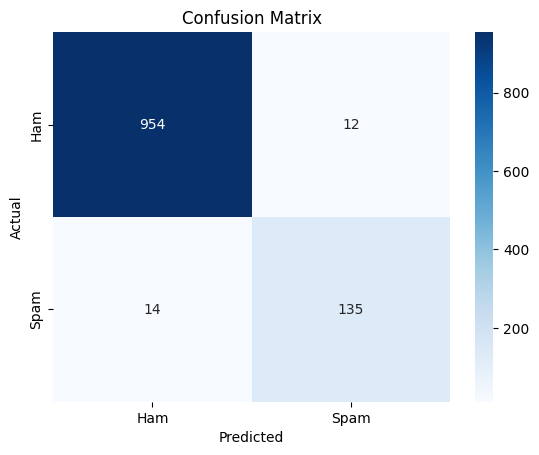

In [6]:
# ===============================
# 6️⃣ Evaluate Model
# ===============================
best_model = grid.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)

# F1 Score
f1 = f1_score(y_test, y_pred)
print("F1 Score on Test Set:", f1)

# Detailed classification report
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


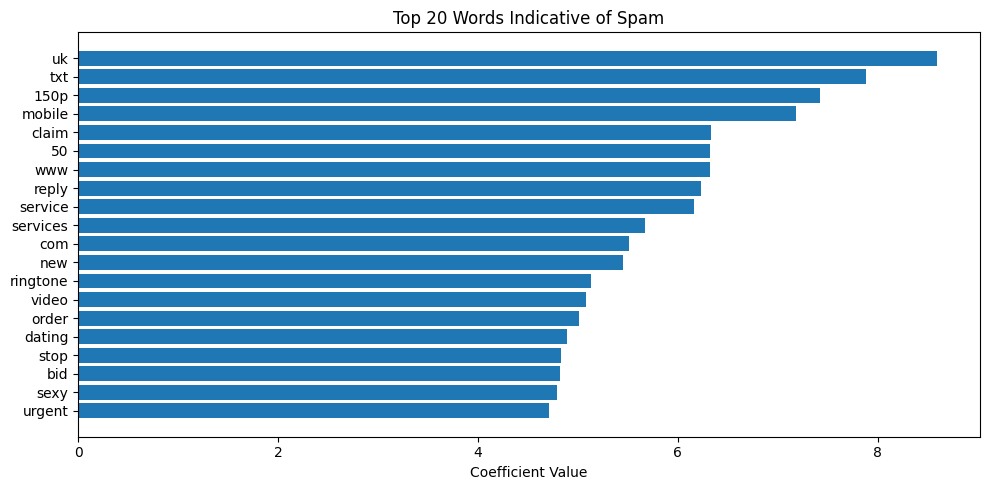

In [7]:


# ===============================
# 7️⃣ Extract Top Spam Words
# ===============================
tfidf = best_model.named_steps['tfidf']
clf = best_model.named_steps['clf']

feature_names = np.array(tfidf.get_feature_names_out())
coefficients = clf.coef_[0]

# Top 20 spam indicative words (highest coefficients)
top_idx = np.argsort(coefficients)[-20:]
top_words = feature_names[top_idx]
top_scores = coefficients[top_idx]

plt.figure(figsize=(10,5))
plt.barh(top_words, top_scores)
plt.title("Top 20 Words Indicative of Spam")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

In [8]:


# ===============================
# 8️⃣ Save Model & Metrics
# ===============================
joblib.dump(best_model, "../models/spam_pipeline.joblib")

metrics = {
    "f1_score": float(f1),
    "best_params": grid.best_params_
}

pd.DataFrame([metrics]).to_json("../models/metrics.json", orient='records', indent=2)

print("Model and metrics saved successfully!")

Model and metrics saved successfully!


In [9]:
### imporve 1️⃣ Improve the Model

In [10]:
TfidfVectorizer(stop_words="english", max_features=2000, ngram_range=(1,2))

TfidfVectorizer(max_features=2000, ngram_range=(1, 2), stop_words='english')